## Library Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, deque
from tqdm import tqdm
import random
import copy
from PIL import Image
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import time
from collections import defaultdict
from pprint import pprint


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
org_path="/mnt/Velocity_Vault/Project_Storage/raw_dataset/"

In [26]:
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"
dataset_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
# dataset_path = "/mnt/Velocity_Vault/Project_Storage/stereo_ML_dataset/"

left_patch_memmap = "left_patch.dat"
left_feat_memmap = "left_feat.dat"
right_strip_memmap = "right_strip.dat"
right_feat_memmap = "right_feat.dat"
patch_disparity_memmap = "patch_disp.dat"

## PLotting Functions

In [4]:

def display_image_array(img_array):
    
    # print(img_array.shape)

    
    """Display a numpy image array (2D or 3D) without axes."""
    plt.figure()
    if len(img_array.shape) == 3:  # RGB image
        plt.imshow(img_array)
    else:  # Grayscale
        plt.imshow(img_array, cmap='gray')
    plt.axis('off')
    plt.show()
    

def display_image_array_bulk(img_list):
    
    # print(img_array.shape)

    for img_array in img_list:
    
        """Display a numpy image array (2D or 3D) without axes."""
        plt.figure()
        if len(img_array.shape) == 3:  # RGB image
            plt.imshow(img_array)
        else:  # Grayscale
            plt.imshow(img_array, cmap='gray')
        plt.axis('off')
        plt.show()

In [5]:


def resize_image_array(image_array, scale_factor):
    # Convert array to PIL Image
    if len(image_array.shape) == 2:
        # Grayscale image
        img = Image.fromarray(image_array)
    elif len(image_array.shape) == 3:
        # RGB/RGBA image
        img = Image.fromarray(image_array.astype('uint8'))
    else:
        raise ValueError("Input array must be 2D (grayscale) or 3D (color)")
    
    # Calculate new dimensions
    width, height = img.size
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)
    
    # Resize using Lanczos resampling (high quality)
    resized_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Convert back to numpy array
    resized_array = np.array(resized_img)
    
    # Preserve original dtype for grayscale
    if len(image_array.shape) == 2:
        resized_array = resized_array.astype(image_array.dtype)
    
    return resized_array

In [6]:
def plot_disp_array(data_array,colourbar=False):
    
    # print(data_array.shape)
    
    plt.figure(figsize=(6, 6))
    img = plt.imshow(data_array, cmap='viridis')
    plt.axis('off')
    if colourbar:
        cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
        cbar.set_label('Value Scale', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_viridis_matrix(matrix):
    # Visualize results
    plt.figure(figsize=(12, 5))
    plt.imshow(matrix, cmap='viridis')
    plt.title('Matrix')
    plt.colorbar()

In [8]:
def display_six_arrays_with_cbar(img1, img2, img3, img4, disp1, disp2, 
                                show_colorbar=False, figsize=(15, 10)):
    """
    Display 6 arrays in a 3x2 grid layout with optional colorbars for disparity maps.
    
    Parameters:
    img1, img2, img3, img4: Image arrays (2D or 3D RGB)
    disp1, disp2: Disparity arrays (2D, displayed with viridis colormap)
    show_colorbar: Whether to show colorbars for disparity maps
    figsize: Tuple specifying the figure size (width, height)
    """
    if show_colorbar:
        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    else:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    
    # First row: img1 and img2
    if len(img1.shape) == 3:
        axes[0, 0].imshow(img1)
    else:
        axes[0, 0].imshow(img1, cmap='gray')
    axes[0, 0].axis('off')
    
    if len(img2.shape) == 3:
        axes[0, 1].imshow(img2)
    else:
        axes[0, 1].imshow(img2, cmap='gray')
    axes[0, 1].axis('off')
    
    # Second row: img3 and img4
    if len(img3.shape) == 3:
        axes[1, 0].imshow(img3)
    else:
        axes[1, 0].imshow(img3, cmap='gray')
    axes[1, 0].axis('off')
    
    if len(img4.shape) == 3:
        axes[1, 1].imshow(img4)
    else:
        axes[1, 1].imshow(img4, cmap='gray')
    axes[1, 1].axis('off')
    
    # Third row: disp1 and disp2
    im1 = axes[2, 0].imshow(disp1, cmap='viridis')
    axes[2, 0].axis('off')
    if show_colorbar:
        plt.colorbar(im1, ax=axes[2, 0], fraction=0.046, pad=0.04)
    
    im2 = axes[2, 1].imshow(disp2, cmap='viridis')
    axes[2, 1].axis('off')
    if show_colorbar:
        plt.colorbar(im2, ax=axes[2, 1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

## Loading Data

In [9]:
import pickle

def load_variable(file_location):
    with open(file_location, 'rb') as f:
        return pickle.load(f)
    
variable_org_path = "/mnt/Velocity_Vault/Project_Storage/stereo_ML_dataset/raw_images/"

calib_list = load_variable(variable_org_path+"calib.pkl")
gray_image_list = load_variable(variable_org_path+"image.pkl")
truth_image_list = load_variable(variable_org_path+"truth.pkl")


# ......................

# calib_files = []
# truth_files = [{'org':[],'flip':[]}]
# image_files = [[{'org':[],'flip':[]}]]

# {"index":i,'left':truth_l,'right':truth_r}

#............................

## Patch Generation

In [4]:
import numpy as np
import cv2
from scipy.fftpack import dct

import numpy as np
import cv2
from scipy.fftpack import dct

def compute_features(patch, eps=1e-6):
    
    patch = patch.astype(np.float32)
    patch_normal = (patch * 255).astype(np.uint16)

    # 1. Mean, Std, Skewness
    mean_val = patch.mean()
    std_val = np.std(patch) / 0.5  # normalize to ~[0,1]
    skew_val = np.mean(((patch - mean_val) / (np.std(patch) + eps)) ** 3)
    skew_val = (skew_val + 2) / 4  # map roughly to [0,1]

    # 2. DCT Mean
    patch_dct = dct(dct(patch.T, norm='ortho').T, norm='ortho')
    dct_coeffs = patch_dct[:5, :5].flatten()
    dct_mean = np.mean(np.abs(dct_coeffs))
    dct_mean = np.clip(dct_mean / 10.0, 0, 1)  # mild normalization

    # 3. Entropy
    hist, _ = np.histogram(patch_normal, bins=256, range=(0, 255))
    p = hist / (hist.sum() + eps)
    entropy = -np.sum(p * np.log2(p + eps)) / 8.0  # normalize to ~[0,1]

    # 4. Sobel gradients
    gx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch, cv2.CV_32F, 0, 1, ksize=3)
    sobel_x_n = (gx.mean() + 1) / 2  # map [-1,1] → [0,1]
    sobel_y_n = (gy.mean() + 1) / 2

    # Combine 7 features
    features = np.array([
        mean_val, std_val, skew_val, dct_mean, entropy, sobel_x_n, sobel_y_n
    ], dtype=np.float32)

    # Clip to [0,1] for safety
    features = np.clip(features, 0.0, 1.0)

    return features


def feature_error(feat1,feat2):
    
    diff = np.abs(feat1-feat2)
    diff_bool = np.zeros_like(diff,dtype=np.bool_)
    
    diff_bool[0] = diff[0]>0.03
    diff_bool[1] = diff[1]>0.05
    diff_bool[2] = diff[2]>0.08
    diff_bool[3] = diff[3]>0.06
    diff_bool[4] = diff[4]>0.05
    diff_bool[5] = diff[5]>0.06
    diff_bool[6] = diff[6]>0.06
    
    final = diff_bool[0] or diff_bool[1] or diff_bool[2] or diff_bool[3] or diff_bool[4] or diff_bool[5] or diff_bool[6] 

    return final    


def generate_patches_strips(main_path, patch_shape, target, min_disp = 0,max_disp=100, maximum_tries=1000,flush_interval=10000,feat_dim=13,disp_skip=2):
    
    eff_min_disp = min_disp//(disp_skip+1)
    eff_max_disp = max_disp//(disp_skip+1)
    
    patch_list = np.memmap(main_path+left_patch_memmap, dtype=np.float16, mode='w+', shape=(target, patch_shape[0], patch_shape[1]))
    patch_feat =np.memmap(main_path+left_feat_memmap, dtype=np.float16, mode='w+', shape=(target, feat_dim))
    strip_list = np.memmap(main_path+right_strip_memmap, dtype=np.float16, mode='w+', shape=(target, eff_max_disp-eff_min_disp, patch_shape[0], patch_shape[1]))
    strip_feat =np.memmap(main_path+right_feat_memmap, dtype=np.float16, mode='w+', shape=(target,  eff_max_disp-eff_min_disp, feat_dim))
    disp_list = np.memmap(main_path+patch_disparity_memmap, dtype=np.int16, mode='w+', shape=(target,))
    
    pbar = tqdm(range(target), desc="Generating patches")
    
    for i in pbar:
        
        try_count = 0
        patch_found = False
        
        choices = ['org','flip']
        side = np.random.choice(choices)
        
        truth_random = np.random.choice(truth_image_list[side])
        truth_index=truth_random['index']
        image_random = np.random.choice(gray_image_list[side][truth_index])
        
        while try_count < maximum_tries and not patch_found:
            
            disp_patch = truth_random['left']
            patch_image = image_random['left']
            strip_image = image_random['right']
            
            image_height, image_width = disp_patch.shape
            
            y_min = np.random.randint(0, image_height - patch_shape[0])
            x_min = np.random.randint(max_disp, image_width - patch_shape[1])
            y_max = y_min + patch_shape[0]
            x_max = x_min + patch_shape[1]
            
            disp_mask = disp_patch[y_min:y_max, x_min:x_max]
            truth_disp = np.median(disp_mask)
            
            if min_disp <= truth_disp < max_disp:
                
                eff_truth_disp = (truth_disp//(disp_skip+1) - eff_min_disp).astype(np.int16)
            
                image_patch = patch_image[y_min:y_max, x_min:x_max].astype('float16') / 255.0
                image_feat = compute_features(image_patch)
                
                image_strip = np.empty(shape=(eff_max_disp-eff_min_disp,patch_shape[0],patch_shape[1]),dtype=np.float16)
                
                feat_disp = np.empty(shape=(eff_max_disp-eff_min_disp,feat_dim),dtype=np.float16)
                
                pointing_disp = int((truth_disp//(disp_skip+1))*(disp_skip+1))
                
                check_strip = strip_image[y_min:y_max, (x_min-pointing_disp):(x_max-pointing_disp)].astype('float16') / 255.0
                check_feat = compute_features(check_strip)
                
                if not feature_error(image_feat, check_feat):
                    
            
                    for temp_disp in range(eff_max_disp-eff_min_disp):
                        
                        
                        eff_disp = int(temp_disp*(disp_skip+1) + min_disp)
                        
                        image_strip[temp_disp] = strip_image[y_min:y_max, (x_min-eff_disp):(x_max-eff_disp)].astype('float16') / 255.0
                        feat_disp[temp_disp] = compute_features(image_strip[temp_disp])
                        
                    
                    patch_list[i] = image_patch
                    patch_feat[i] = image_feat
                    
                    strip_list[i] = image_strip
                    strip_feat[i] = feat_disp
                    
                    disp_list[i] = eff_truth_disp
                    
                    patch_found = True
            
            try_count += 1
        
        if not patch_found:
            print(f"Warning: Could not find suitable patch for index {i} after {maximum_tries} tries")
            
            patch_list[i] = np.zeros(patch_shape, dtype=np.uint8)
            disp_list[i] = 0
            
            break
        
        if (i + 1) % flush_interval == 0:
            patch_list.flush()
            patch_feat.flush()
            disp_list.flush()
            strip_list.flush()
            strip_feat.flush()
    
    patch_list.flush()
    patch_feat.flush()
    disp_list.flush()
    strip_list.flush()
    strip_feat.flush()
    
    return patch_list, patch_feat, strip_list, strip_feat, disp_list

resize_fraction = 1
resize_factor = 1/resize_fraction

minimum_disparity = 35
maximum_disparity = int((235)*resize_factor)

# global_patch_shape = (min(global_image_shape//30),min(global_image_shape//30))
global_patch_shape = (16,16)

feat_dim = 7

d_skip = 0

sample_target = int((2**18+2)*(10/8))
# sample_target = 100

print(sample_target, (maximum_disparity//(d_skip+1)), global_patch_shape[0], global_patch_shape[1])


327682 235 16 16


In [11]:


train_path = dataset_path+"train/"
test_path = dataset_path+"test/"

train_split=int(0.8*sample_target)
test_split=int(0.2*sample_target)

patch_list, patch_feat, strip_list, strip_feat, disp_list = generate_patches_strips(train_path,global_patch_shape,
                                                                                    target=train_split,max_disp=maximum_disparity,
                                                                                    min_disp=minimum_disparity,
                                                                                    feat_dim=feat_dim,disp_skip=d_skip,
                                                                                    maximum_tries=1000000)

# patch_list, disp_list, strip_list = generate_patches_strips(test_path,global_patch_shape,target=test_split,max_disp=maximum_disparity,maximum_tries=100000)


Generating patches: 100%|██████████| 262145/262145 [1:45:02<00:00, 41.59it/s]  


In [ ]:
# org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
# dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/"
# # dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/sampled/"

# # -------------------------
# # Load memmap datasets
# # -------------------------
# left_patch_memmap = dataset_org_path + "left_patch.dat"
# left_feat_memmap = dataset_org_path + "left_feat.dat"
# right_strip_memmap = dataset_org_path + "right_strip.dat"
# right_feat_memmap = dataset_org_path + "right_feat.dat"
# patch_disparity_memmap = dataset_org_path + "patch_disp.dat"

# target = 262145
# patch_shape = (16,16)
# feature_dimension=7
# eff_Dmax=200

# patch_list  = np.memmap(left_patch_memmap, dtype=np.float16, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
# patch_feat =np.memmap(left_feat_memmap, dtype=np.float16, mode='r', shape=(target, feature_dimension))

# strip_list  = np.memmap(right_strip_memmap, dtype=np.float16, mode='r', shape=(target, eff_Dmax, patch_shape[0], patch_shape[1] ))
# strip_feat =np.memmap(right_feat_memmap, dtype=np.float16, mode='r', shape=(target,  eff_Dmax, feature_dimension))

# disp_list   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))


(262145, 16, 16)
(262145, 7)
(262145, 200, 16, 16)
(262145, 200, 7)
(262145,)
235
235



0.0
0.43
1.0
0.0
0.4236
1.0



0
64.0
199


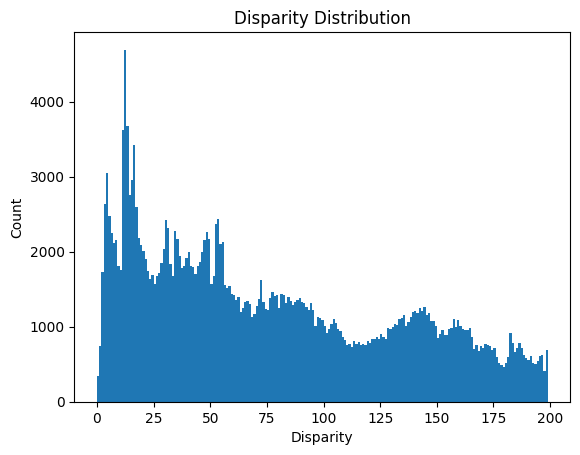

In [7]:


print(patch_list.shape)
print(patch_feat.shape)
print(strip_list.shape)
print(strip_feat.shape)
print(disp_list.shape)
print(maximum_disparity)
print(maximum_disparity//(d_skip+1))

for i in range(0,0):
    
    disp = disp_list[i]
    
    image_array = patch_list[i]
    strip_arr = strip_list[i][disp]
    display_image_array(image_array*255)
    display_image_array(strip_arr*255)
    
    print(patch_feat[i])
    print(strip_feat[i][disp])
    print("Error : ",np.mean(np.abs(strip_feat[i][disp]-patch_feat[i])))
    print(disp*(d_skip+1)+minimum_disparity)
    
print("\n\n")

print(np.min(patch_feat))
print(np.median(patch_feat))
print(np.max(patch_feat))
print(np.min(strip_feat))
print(np.median(strip_feat))
print(np.max(strip_feat))

print("\n\n")

print(np.min(disp_list))
print(np.median(disp_list))
print(np.max(disp_list))


classes = np.unique(disp_list)

import matplotlib.pyplot as plt
plt.hist(disp_list, bins=np.arange(disp_list.min(), disp_list.max()+1))
plt.title("Disparity Distribution")
plt.xlabel("Disparity")
plt.ylabel("Count")
plt.show()
    

In [37]:


import random
from collections import defaultdict
import statistics

def create_index_dict(arr):
    
    index_dict = defaultdict(list)
    for idx, value in enumerate(arr):
        index_dict[value].append(idx)
    
    counts = [len(indices) for indices in index_dict.values()]
    min_count = int(np.min(counts)) if counts else 0
    mean_count = int(np.mean(counts)) if counts else 0
    median_count = int(np.median(counts)) if counts else 0
    max_count = int(np.max(counts)) if counts else 0
    
    return dict(index_dict),{"Min":min_count, "Mean":mean_count, "Median":median_count, "Max":max_count}

def balance_indices(indices, current_count, target_count):
    
    if current_count == 0:
        return indices
    
    # if current_count < target_count:
    #     additional_indices = random.choices(indices, k=target_count - current_count)
    #     return indices + additional_indices
    
    elif current_count > target_count:
        return random.sample(indices, target_count)
    
    else:
        # No change needed
        return indices

def create_balanced_dict(index_dict, target_count):
    
    balanced_dict = {}
    
    for value, indices in index_dict.items():
        current_count = len(indices)
        balanced_indices = balance_indices(indices, current_count, target_count)
        balanced_dict[value] = balanced_indices
    
    return balanced_dict

def reconstruct_from_indices_dict(sample_size, original_arr, indices_dict, file_location,  flush_interval=10000):
    original_shape = original_arr.shape
    original_dtype = original_arr.dtype
    
    new_shape = (sample_size,) + original_shape[1:]
    
    memmap_arr = np.memmap(file_location, dtype=original_dtype, mode='w+', shape=new_shape)
    
    counter = 0
    total_elements = sum(len(indices) for indices in indices_dict.values())
    
    with tqdm(total=total_elements, desc="Writing to memmap") as pbar:
        for indices_list in indices_dict.values():
            for idx in indices_list:
                if 0 <= idx < len(original_arr):
                    memmap_arr[counter] = original_arr[idx]
                    counter += 1
                    pbar.update(1)
                    
                    if counter % flush_interval == 0:
                        memmap_arr.flush()
                else:
                    pbar.update(1)
        
        memmap_arr.flush()
    
    return memmap_arr

def capped_list_sum(data_dict,target):
    
    total = 0
    for key, value in data_dict.items():
        lst = len(value)
        total += min(lst, target)
    return total



In [38]:
index_dict,count_stat = create_index_dict(disp_list)

print("Median Count : ",count_stat)

Median Count :  {'Min': 337, 'Mean': 1310, 'Median': 1161, 'Max': 4692}


In [ ]:
target_count = 700
current_count = capped_list_sum(index_dict,target_count)
print(current_count)

sampled_dict = create_balanced_dict(index_dict,target_count)

print(capped_list_sum(sampled_dict,target_count+2))

131212
131212


In [40]:

resampled_train_path = dataset_path+"train/sampled/"

sampled_patch_list = reconstruct_from_indices_dict(current_count, patch_list,sampled_dict, resampled_train_path+left_patch_memmap)
sampled_patch_feat = reconstruct_from_indices_dict(current_count, patch_feat,sampled_dict, resampled_train_path+left_feat_memmap)
sampled_strip_list = reconstruct_from_indices_dict(current_count, strip_list,sampled_dict, resampled_train_path+right_strip_memmap)
sampled_strip_feat = reconstruct_from_indices_dict(current_count, strip_feat,sampled_dict, resampled_train_path+right_feat_memmap)
sampled_disp_list = reconstruct_from_indices_dict(current_count, disp_list,sampled_dict, resampled_train_path+patch_disparity_memmap)

resample_target = int (len(sampled_patch_list) * len(index_dict) *(10/8))

Writing to memmap: 100%|██████████| 131212/131212 [00:00<00:00, 1512484.00it/s]


(131212, 16, 16)
(131212, 7)
(131212, 200, 16, 16)
(131212, 200, 7)
(131212,)
235
235



0.4338
1.0
0.4275
1.0


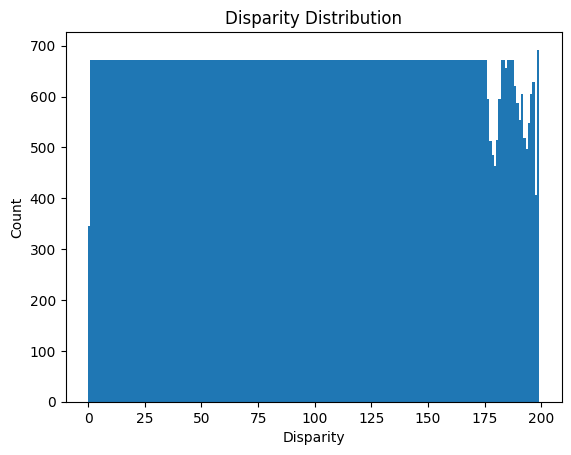

In [44]:


print(sampled_patch_list.shape)
print(sampled_patch_feat.shape)
print(sampled_strip_list.shape)
print(sampled_strip_feat.shape)
print(sampled_disp_list.shape)
print(maximum_disparity)
print(maximum_disparity//(d_skip+1))

for i in range(0,0):
    
    disp = sampled_disp_list[i]
    
    image_array = sampled_patch_list[i]
    strip_arr = sampled_strip_list[i][disp]
    display_image_array(image_array*255)
    display_image_array(strip_arr*255)
    
    print(sampled_patch_feat[i])
    print(sampled_strip_feat[i][disp])
    print("Error : ",np.mean(np.abs(sampled_strip_feat[i][disp]-sampled_patch_feat[i])))
    print(disp*(d_skip+1)+minimum_disparity)
    
print("\n\n")
    
print(np.median(sampled_patch_feat))
print(np.max(sampled_patch_feat))
print(np.median(sampled_strip_feat))
print(np.max(sampled_strip_feat))


import matplotlib.pyplot as plt
plt.hist(sampled_disp_list, bins=np.arange(sampled_disp_list.min(), sampled_disp_list.max()+1))
plt.title("Disparity Distribution")
plt.xlabel("Disparity")
plt.ylabel("Count")
plt.show()


In [45]:
print(np.min(sampled_disp_list))
print(np.median(sampled_disp_list))
print(np.max(sampled_disp_list))

0
98.0
199


In [46]:
dataset_detail = []

dataset_detail=[global_patch_shape[0],global_patch_shape[1],resample_target,maximum_disparity, minimum_disparity,resize_fraction,feat_dim,d_skip]

dataset_detail=np.array(dataset_detail)

np.save(dataset_org_path+"detail.npy",dataset_detail, allow_pickle=True)
